In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_btc = pd.read_csv("./dataset/portfolio_data.csv")

In [21]:
data_btc.columns

Index(['Date', 'BTC'], dtype='str')

In [3]:
data_btc = data_btc.drop(["AMZN", "DPZ", "NFLX"], axis=1)

In [4]:
data_btc.head()

,Date,BTC
0,5/1/2013,106.250000
1,5/2/2013,98.099998
2,5/3/2013,112.900002
3,5/6/2013,109.599998
4,5/7/2013,113.199997


In [5]:
data_btc.info()

<class 'pandas.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1520 non-null   str    
 1   BTC     1520 non-null   float64
dtypes: float64(1), str(1)
memory usage: 23.9 KB


In [6]:
data_btc.shape

(1520, 2)

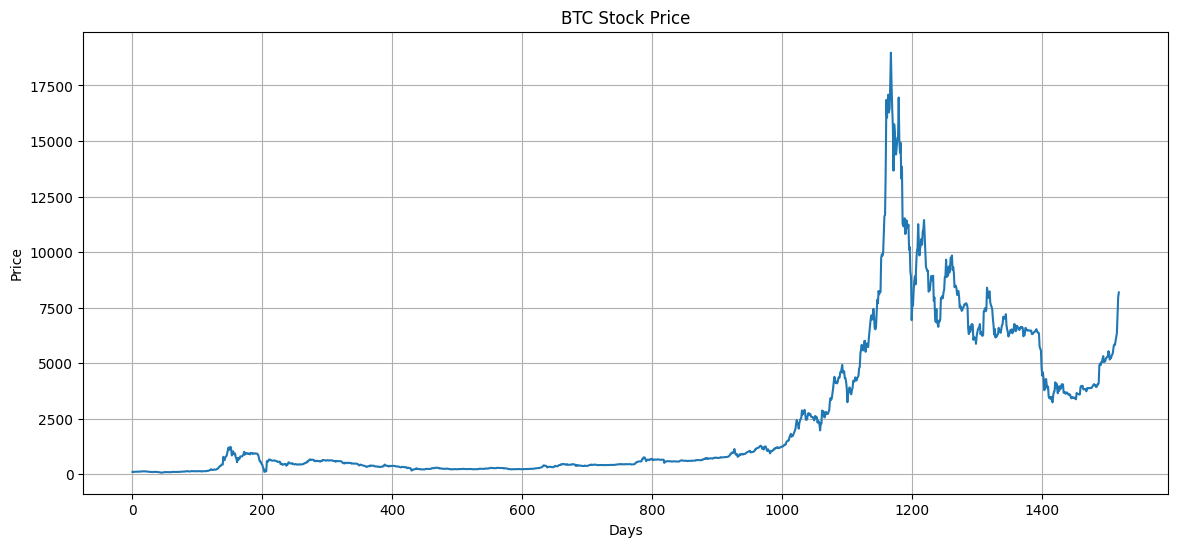

In [8]:
plt.figure(figsize=(14, 6))
plt.plot(data_btc['BTC'])
plt.title("BTC Stock Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.grid()
plt.show()

In [9]:
price = data_btc["BTC"].values
X = []
y = []
day = 365
for index in range(len(price) - day):
    X.append(price[index: index + day])
    y.append(price[index + day])
    
X = np.array(X)
y= np.array(y)

In [10]:
print(X.shape)
print(y.shape)

(1155, 365)
(1155,)


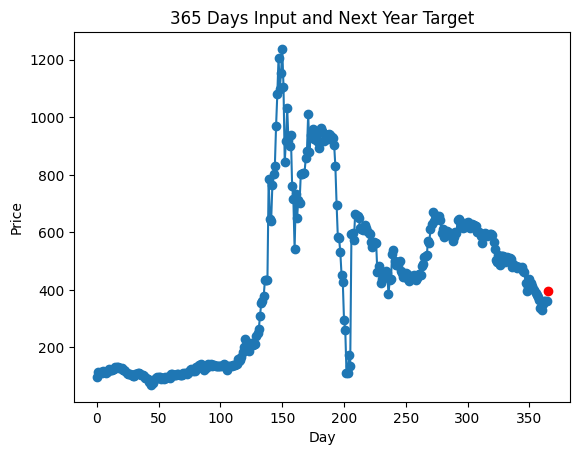

In [11]:
plt.plot(X[1], marker= 'o')
plt.plot(365, y[1], 'ro')
plt.xlabel("Day")
plt.ylabel("Price")
plt.title("365 Days Input and Next Year Target")
plt.show()

In [12]:
train_size = int(len(X)* 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [13]:
from sklearn.preprocessing import MinMaxScaler

model = MinMaxScaler()
X_train = model.fit_transform(X_train)
X_test = model.transform(X_test)

## SVM

In [14]:
from sklearn.svm import SVR

svm = SVR(C=200, kernel="linear", gamma="scale" , epsilon=3)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

In [15]:
print("Train:", svm.score(X_train, y_train))
print("Test:", svm.score(X_test, y_test))

Train: 0.978952810514605
Test: 0.6424360562220821


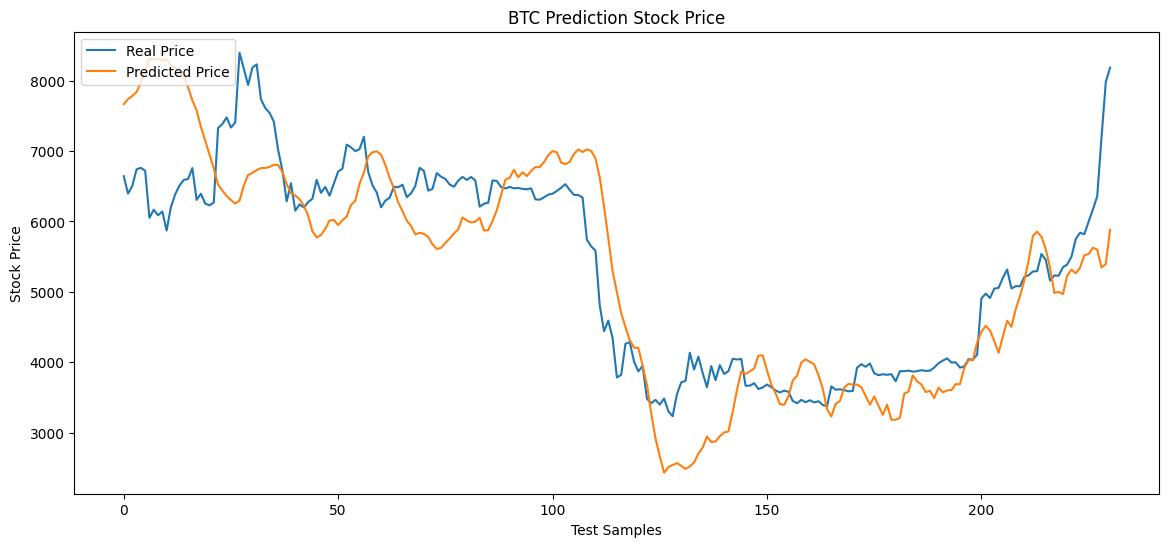

In [16]:
plt.figure(figsize=(14, 6))
plt.plot(y_test, label="Real Price")
plt.plot(svm_pred, label="Predicted Price")
plt.title("BTC Prediction Stock Price")
plt.xlabel("Test Samples")
plt.ylabel("Stock Price")
plt.legend(loc='upper left')
plt.show()

In [17]:
last_365_days = price[-365:]
# print(f"Last 30 Days:", last_365_days)

last_365_days = model.transform([last_365_days])
pred = svm.predict(last_365_days)
print(f"Next day Prediction:", pred)

Next day Prediction: [6245.31492086]


### Linear Regression

In [18]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [19]:
print("Train:", lr.score(X_train, y_train))
print("Test:", lr.score(X_test, y_test))

Train: 0.9986688958967808
Test: -6.233570742464018


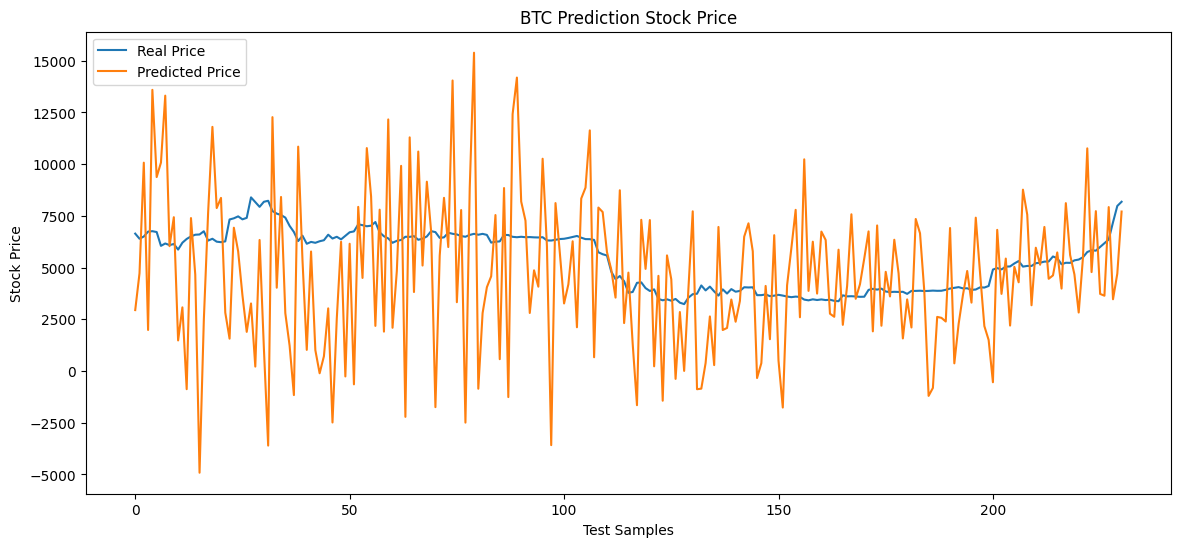

In [20]:
plt.figure(figsize=(14, 6))
plt.plot(y_test, label="Real Price")
plt.plot(lr_pred, label="Predicted Price")
plt.title("BTC Prediction Stock Price")
plt.xlabel("Test Samples")
plt.ylabel("Stock Price")
plt.legend(loc='upper left')
plt.show()